# Data & AI Job Market — Salary Prediction
## Notebook 3 — Can We Predict a Salary From the Posting?

Author: Francisco Martinez Grecco
Project: [Data-ai-jobs-analysis](https://github.com/FranciscoMartinezGrecco/Data-ai-jobs-analysis)
Previous notebooks: `01_eda.ipynb`, `02_business_insights.ipynb`

## Purpose

The first two notebooks described the market: what salaries look like and which factors move them. This one asks the natural next question: given the attributes of a job posting (role, experience level, country, company size, remote setup), how well can we actually predict the salary?

A couple of caveats before starting. The goal here is the modeling workflow itself (feature preparation, honest baselines, validation, interpretation), not squeezing out the last decimal of accuracy. And with only 565 postings and fairly coarse features, the expectations should stay modest: a big part of what sets an individual salary, like specific skills, the company, or how someone negotiated, simply isn't in this dataset. Seeing how far those visible attributes actually get us is part of the point.

## Approach

1. Move the target to log scale to tame the right tail.
2. Select features, avoiding leakage and near-constant columns.
3. Build a preprocessing + model pipeline with scikit-learn.
4. Compare a median baseline, linear regression, random forest and gradient boosting.
5. Interpret the best model with permutation importance and error analysis.

---

## Section 1 — Setup and Data

Same loading and cleaning pipeline as the previous notebooks, plus the modeling helpers from `src/model.py`.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.inspection import permutation_importance

# Add the parent folder to the path so we can import from src/
import sys
sys.path.append('..')

from src.clean import load_raw_data, clean_salaries_df
from src.features import build_features
from src.model import (collapse_rare_categories, build_preprocessor,
                       build_model_pipelines, regression_metrics)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Same style as the other notebooks
sns.set_theme(style='whitegrid', palette='viridis')

# One seed for everything, so the notebook gives the same numbers on every run
RANDOM_STATE = 42

print("Imports done.")

Imports done.


In [2]:
# Load and prepare the data with the same pipeline as Notebooks 1 and 2
df_raw = load_raw_data('../data/raw/ds_salaries.csv')
df = clean_salaries_df(df_raw)
df = build_features(df)

print(f"\nDataset ready: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Median salary: ${df['salary_in_usd'].median():,.0f}")

Loaded 607 rows × 12 columns
Removed 42 duplicate rows
Cleaned dataset: 565 rows × 11 columns
Features added. New shape: 565 rows × 14 columns

Dataset ready: 565 rows, 14 columns
Median salary: $100,000


## Section 2 — The Target in Log Scale

Salaries are heavily right-skewed, something Notebook 1 already showed in detail (`salary_log_transform.png`). Training on raw dollar amounts would let a handful of $400k+ salaries dominate the fit, so the models work with `log1p(salary_in_usd)` and predictions are converted back to dollars for reporting. The log transform actually overshoots a little and leaves a mild left tail, but it is far closer to symmetric than the raw values.

In [3]:
y_usd = df['salary_in_usd']
y_log = np.log1p(y_usd)

print(f"Skewness of salary_in_usd:  {y_usd.skew():.2f}")
print(f"Skewness after log1p:      {y_log.skew():.2f}")

Skewness of salary_in_usd:  1.73
Skewness after log1p:      -1.20


## Section 3 — Feature Selection and Engineering

The dataset offers eight potential predictors, but not all of them make the cut, and the two geographic columns need work first: `job_title` and `company_location` both have 50 unique values, far too many to one-hot encode with only 565 rows.

In [4]:
# job_title and company_location have 50 categories each. One-hot
# encoding them as-is would create a sparse matrix full of columns the
# model sees three or four times. We keep the frequent categories
# (top 10 titles cover ~80% of postings) and group the rest as Other.
model_df = df.copy()
model_df['job_title_grp'] = collapse_rare_categories(model_df['job_title'], top_n=10)
model_df['location_grp'] = collapse_rare_categories(model_df['company_location'], top_n=8)

# Whether the employee lives in a different country than the company.
# Same flag used for the cross-border analysis in Notebook 2.
model_df['cross_border'] = (model_df['employee_residence'] != model_df['company_location']).astype(int)

print(f"job_title: 50 categories -> {model_df['job_title_grp'].nunique()}")
print(f"company_location: 50 categories -> {model_df['location_grp'].nunique()}")
print(f"cross-border postings: {model_df['cross_border'].sum()}")

job_title: 50 categories -> 11
company_location: 50 categories -> 9
cross-border postings: 51


In [5]:
# Final feature set. A few deliberate exclusions:
# - salary and salary_currency would leak the target directly
# - employment_type is 97% Full-Time, so it carries almost no signal
# - employee_residence is redundant once we have location + cross_border
# - remote_ratio is just the numeric version of remote_category
nominal_features = ['job_title_grp', 'location_grp', 'remote_category']
numeric_features = ['experience_rank', 'company_size_rank', 'work_year', 'cross_border']

X = model_df[nominal_features + numeric_features]

X_train, X_test, ylog_train, ylog_test, yusd_train, yusd_test = train_test_split(
    X, y_log, y_usd, test_size=0.2, random_state=RANDOM_STATE)

print(f"Features: {list(X.columns)}")
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Features: ['job_title_grp', 'location_grp', 'remote_category', 'experience_rank', 'company_size_rank', 'work_year', 'cross_border']
Train: 452 rows | Test: 113 rows


## Section 4 — Preprocessing Pipeline

Everything goes through a single `ColumnTransformer` wrapped in a scikit-learn `Pipeline` per model. This is more than tidiness: because preprocessing lives inside the pipeline, it gets refit on the training portion of every cross-validation fold, so no information from the validation folds leaks into the encoders or the scaler.

In [6]:
# One-hot for the nominal columns, standard scaling for the numeric
# ones. Scaling is irrelevant for the trees but helps the linear model,
# and sharing one preprocessor keeps all pipelines identical.
preprocessor = build_preprocessor(nominal_features, numeric_features)
models = build_model_pipelines(preprocessor, random_state=RANDOM_STATE)

print("Models to compare:")
for name in models:
    print(f"  - {name}")

Models to compare:
  - Baseline (median)
  - Linear Regression
  - Random Forest
  - Gradient Boosting


## Section 5 — Baselines First

A model is only as good as what it beats. The floor is a dummy model that predicts the median salary for everyone; the second reference is a plain linear regression on the prepared features. Whatever the ensembles do later has to be judged against these two numbers.

In [7]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name in ['Baseline (median)', 'Linear Regression']:
    pipe = models[name]
    cv = cross_val_score(pipe, X_train, ylog_train, cv=kfold, scoring='r2')
    pipe.fit(X_train, ylog_train)
    metrics = regression_metrics(yusd_test, pipe.predict(X_test))
    results.append({'Model': name, 'CV R2 (log)': f"{cv.mean():.3f} +/- {cv.std():.3f}", **metrics})

    print(f"{name}")
    print(f"  CV R2 (log, 5-fold): {cv.mean():.3f} +/- {cv.std():.3f}")
    print(f"  Test: MAE ${metrics['MAE']:,.0f} | RMSE ${metrics['RMSE']:,.0f} | R2 {metrics['R2']:.3f}\n")

Baseline (median)


  CV R2 (log, 5-fold): -0.038 +/- 0.029
  Test: MAE $50,959 | RMSE $69,823 | R2 -0.015



Linear Regression
  CV R2 (log, 5-fold): 0.548 +/- 0.061
  Test: MAE $30,380 | RMSE $52,008 | R2 0.437



## Section 6 — Tree Ensembles

Random forest and gradient boosting can pick up interactions the linear model cannot, for example that seniority is worth more inside the US than outside (Notebook 2, Section 5). Whether there is enough data for them to actually find those patterns is what the comparison will tell us. The random forest also gets a light grid search, to see how much tuning changes the picture.

In [8]:
# Same protocol as the baselines: 5-fold CV on the training set,
# final metrics on the held-out test.
for name in ['Random Forest', 'Gradient Boosting']:
    pipe = models[name]
    cv = cross_val_score(pipe, X_train, ylog_train, cv=kfold, scoring='r2')
    pipe.fit(X_train, ylog_train)
    metrics = regression_metrics(yusd_test, pipe.predict(X_test))
    results.append({'Model': name, 'CV R2 (log)': f"{cv.mean():.3f} +/- {cv.std():.3f}", **metrics})

    print(f"{name}")
    print(f"  CV R2 (log, 5-fold): {cv.mean():.3f} +/- {cv.std():.3f}")
    print(f"  Test: MAE ${metrics['MAE']:,.0f} | RMSE ${metrics['RMSE']:,.0f} | R2 {metrics['R2']:.3f}\n")

Random Forest
  CV R2 (log, 5-fold): 0.448 +/- 0.077
  Test: MAE $30,600 | RMSE $52,007 | R2 0.437



Gradient Boosting
  CV R2 (log, 5-fold): 0.488 +/- 0.073
  Test: MAE $29,837 | RMSE $50,351 | R2 0.472



In [9]:
# Light tuning on the random forest. The grid is small on purpose:
# with 452 training rows an exhaustive search would mostly overfit
# the validation folds.
param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': [1, 2, 4],
}

grid = GridSearchCV(models['Random Forest'], param_grid,
                    cv=kfold, scoring='r2', n_jobs=-1)
grid.fit(X_train, ylog_train)

tuned_metrics = regression_metrics(yusd_test, grid.best_estimator_.predict(X_test))
results.append({'Model': 'Random Forest (tuned)',
                'CV R2 (log)': f"{grid.best_score_:.3f}", **tuned_metrics})

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV R2 (log): {grid.best_score_:.3f}")
print(f"Test: MAE ${tuned_metrics['MAE']:,.0f} | RMSE ${tuned_metrics['RMSE']:,.0f} | R2 {tuned_metrics['R2']:.3f}")

Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 400}
Best CV R2 (log): 0.491
Test: MAE $32,482 | RMSE $53,769 | R2 0.398


## Section 7 — Model Comparison

All five configurations side by side, with test metrics in dollars.

In [10]:
comparison = pd.DataFrame(results)
comparison['MAE'] = comparison['MAE'].map('${:,.0f}'.format)
comparison['RMSE'] = comparison['RMSE'].map('${:,.0f}'.format)
comparison['R2'] = comparison['R2'].map('{:.3f}'.format)

print(comparison.to_string(index=False))

# Gradient boosting has the best test numbers, but only by a small
# margin. The plain linear regression is honestly competitive, and
# tuning the forest improved CV while doing slightly worse on the
# test split (with 113 test rows, differences this small are noise).
# The signal in these features is mostly additive. We keep gradient
# boosting as the final model for the interpretation below.
final_model = models['Gradient Boosting']

                Model      CV R2 (log)     MAE    RMSE     R2
    Baseline (median) -0.038 +/- 0.029 $50,959 $69,823 -0.015
    Linear Regression  0.548 +/- 0.061 $30,380 $52,008  0.437
        Random Forest  0.448 +/- 0.077 $30,600 $52,007  0.437
    Gradient Boosting  0.488 +/- 0.073 $29,837 $50,351  0.472
Random Forest (tuned)            0.491 $32,482 $53,769  0.398


## Section 8 — What Drives Predictions, and Where They Fail

Accuracy numbers alone don't say much. The more interesting questions are which features the model actually relies on (and whether that matches what the statistical analysis in Notebook 2 found), plus where the predictions break down.

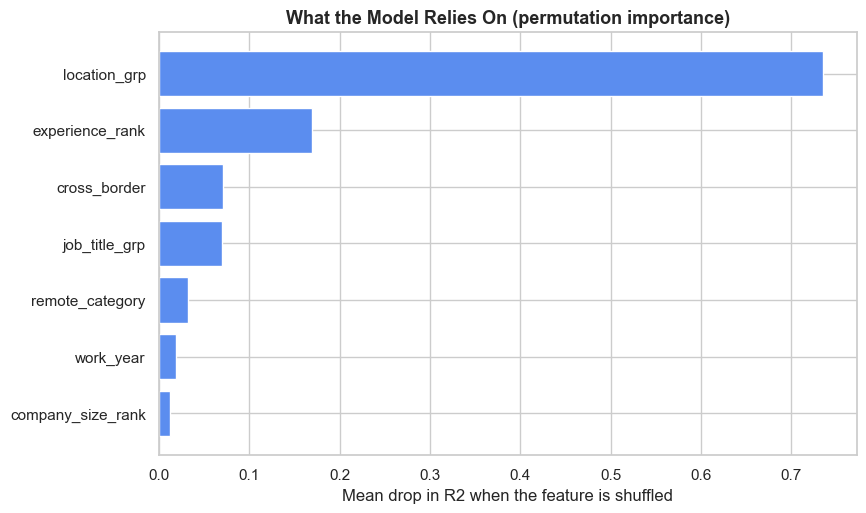

location_grp        0.73
experience_rank     0.17
cross_border        0.07
job_title_grp       0.07
remote_category     0.03
work_year           0.02
company_size_rank   0.01


In [11]:
# Permutation importance on the test set: shuffle one column at a
# time and measure how much R2 drops. Since we permute the raw
# columns (before one-hot), each categorical feature is evaluated
# as a whole instead of dummy by dummy.
perm = permutation_importance(final_model, X_test, ylog_test,
                              n_repeats=10, random_state=RANDOM_STATE, scoring='r2')

importance = pd.Series(perm.importances_mean, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(importance.index, importance.values, color='#5b8def', edgecolor='white')
ax.set_title('What the Model Relies On (permutation importance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean drop in R2 when the feature is shuffled')

plt.savefig('../outputs/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance.sort_values(ascending=False).round(3).to_string())

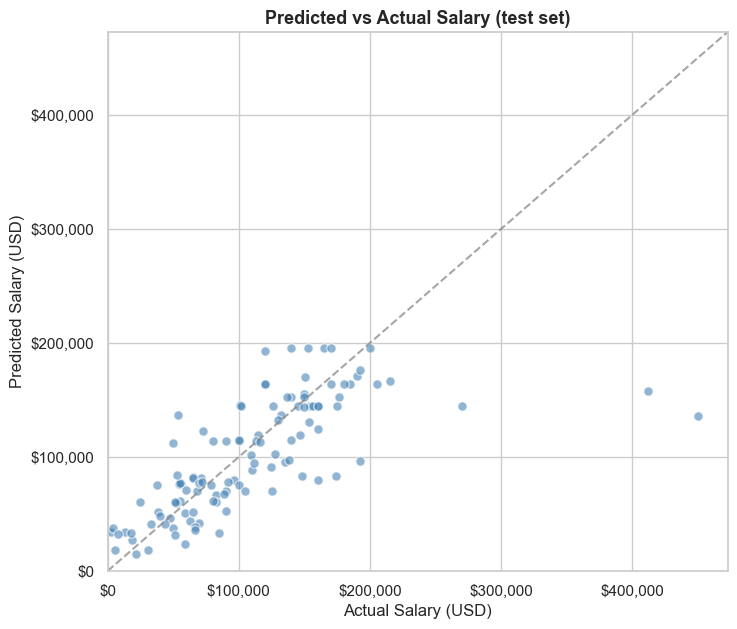

Top 10 salaries in the test set: 10 of 10 underpredicted
  actual mean: $251,226 | predicted mean: $157,304


In [12]:
# Predicted vs actual on the test set. The dashed line is a perfect
# prediction; the interesting part is what happens at the top.
pred_usd = np.expm1(final_model.predict(X_test))

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(yusd_test, pred_usd, s=45, alpha=0.6, color='steelblue', edgecolors='white')

lims = [0, max(yusd_test.max(), pred_usd.max()) * 1.05]
ax.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_title('Predicted vs Actual Salary (test set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Salary (USD)')
ax.set_ylabel('Predicted Salary (USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.savefig('../outputs/figures/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# How badly does it miss at the top of the market?
top = pd.DataFrame({'actual': yusd_test, 'pred': pred_usd}).nlargest(10, 'actual')
print(f"Top 10 salaries in the test set: {(top['pred'] < top['actual']).sum()} of 10 underpredicted")
print(f"  actual mean: ${top['actual'].mean():,.0f} | predicted mean: ${top['pred'].mean():,.0f}")

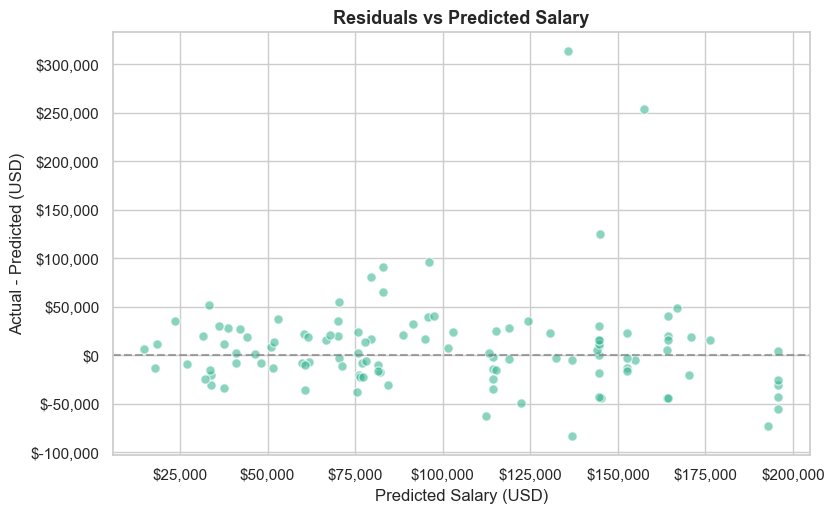

Mean absolute error by region:
            mean  count
region                 
Non-US 22,332.00     53
US     36,466.00     60

Mean absolute error by experience level:
                 mean  count
experience                  
Entry-Level 24,362.00     17
Executive   10,103.00      3
Mid-Level   28,406.00     39
Senior      33,690.00     54


In [13]:
# Residuals against the predicted value. Positive residual = the
# model predicted less than the person actually earns.
residuals = yusd_test - pred_usd

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(pred_usd, residuals, s=45, alpha=0.6, color='#3ab795', edgecolors='white')
ax.axhline(0, color='gray', linestyle='--', alpha=0.7)

ax.set_title('Residuals vs Predicted Salary', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Salary (USD)')
ax.set_ylabel('Actual - Predicted (USD)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.savefig('../outputs/figures/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Where does the error concentrate?
err = pd.DataFrame({
    'abs_err': residuals.abs(),
    'region': np.where(model_df.loc[X_test.index, 'company_location'] == 'US', 'US', 'Non-US'),
    'experience': model_df.loc[X_test.index, 'experience_level'],
})

print("Mean absolute error by region:")
print(err.groupby('region')['abs_err'].agg(['mean', 'count']).round(0))
print("\nMean absolute error by experience level:")
print(err.groupby('experience')['abs_err'].agg(['mean', 'count']).round(0))